In [1]:
import pandas as pd
import math
import re
import numpy as np
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from pathlib import Path
import pandas as pd
from scipy.stats import chi2_contingency
from scipy.stats import shapiro
from scipy.stats import kruskal
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
#sklearn imports
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, precision_recall_curve, \
    PrecisionRecallDisplay
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA #Principal Component Analysis
from sklearn.manifold import TSNE #T-Distributed Stochastic Neighbor Embedding
from sklearn.cluster import KMeans #K-Means Clustering
from sklearn.preprocessing import StandardScaler #used for 'Feature Scaling'
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

#plotly imports
import plotly as py
import plotly.graph_objs as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot


In [2]:
cancer_df_first=pd.read_csv("cancer.xlsx - Sheet1.csv")
cancer_df_first

,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,P1,33,1,2,4,5,4,3,2,2,...,3,4,2,2,3,1,2,3,4,Low
1,P10,17,1,3,1,5,3,4,2,2,...,1,3,7,8,6,2,1,7,2,Medium
2,P100,35,1,4,5,6,5,5,4,6,...,8,7,9,2,1,4,6,7,2,High
3,P1000,37,1,7,7,7,7,6,7,7,...,4,2,3,1,4,5,6,7,5,High
4,P101,46,1,6,8,7,7,7,6,7,...,3,2,4,1,4,2,4,2,3,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,P995,44,1,6,7,7,7,7,6,7,...,5,3,2,7,8,2,4,5,3,High
996,P996,37,2,6,8,7,7,7,6,7,...,9,6,5,7,2,4,3,1,4,High
997,P997,25,2,4,5,6,5,5,4,6,...,8,7,9,2,1,4,6,7,2,High
998,P998,18,2,6,8,7,7,7,6,7,...,3,2,4,1,4,2,4,2,3,High


In [3]:
#fill missing values with the mode of the cplumn although this database didn't have any missing values
#Get the list of all column names from headers
column_headers = list(cancer_df_first.columns.values)
for column_header in column_headers:
    cancer_df_first[column_header]=cancer_df_first[column_header].fillna(cancer_df_first.mode().iloc[0])

In [4]:
#check if there are duplicate ids and change them with an id that is not in the dataframe
# Check if there are any duplicate Patient Ids
if cancer_df_first['Patient Id'].duplicated().any():
    # Generate a new ID for each duplicate ID that is not in the DataFrame
    new_ids = {}
    for duplicate_id in cancer_df_first[cancer_df_first.duplicated(subset='Patient Id')]['Patient Id'].unique():
        i = 1
        new_id = 'P' + str(i)
        while new_id in cancer_df_first['Patient Id'].values or new_id in new_ids.values():
            i += 1
            new_id = 'P' + str(i)
        new_ids[duplicate_id] = new_id

    # Replace the duplicate Patient Ids with the new IDs
    cancer_df_first['Patient Id'] = cancer_df_first['Patient Id'].replace(new_ids)

In [5]:
#removing outliers from age column
Q1 = cancer_df_first.Age.quantile(0.25)
Q3 = cancer_df_first.Age.quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
cancer_df = cancer_df_first[(cancer_df_first.Age>lower_limit)&(cancer_df_first.Age<upper_limit)]
print(lower_limit)
print(upper_limit)

1.875
70.875


In [6]:
#remove outliers from categorical data
for column_header in column_headers: 
    if column_header!='Patient Id' and column_header!='Age' and column_header!='Level':
        
        sorted_df=cancer_df.sort_values(column_header)
        
        bin_range=100
        min_items=10
        # get the first bin_range items in the sorted DataFrame
        first_items = sorted_df.iloc[:bin_range]
        # get the last bin_range items in the sorted DataFrame
        last_items = sorted_df.iloc[-bin_range:]
        
        #delete items with low frequency from first bin
        # get the value counts of the 'Name' column
        value_counts = first_items[column_header].value_counts()
        # get the names that occur less than min_items times
        names_to_remove = value_counts[value_counts < min_items].index
        # remove the rows where the 'Name' column contains a name that occurs less than 10 times
        cancer_df = cancer_df[~cancer_df[column_header].isin(names_to_remove)]

        #delete items with low frequency from last bin
        value_counts = last_items[column_header].value_counts()
        # get the names that occur less than min_items times
        names_to_remove = value_counts[value_counts < min_items].index
        # remove the rows where the 'Name' column contains a name that occurs less than 10 times
        cancer_df = cancer_df[~cancer_df[column_header].isin(names_to_remove)]

In [7]:
#replace high, medium and low in level column with 3, 2 and 1
# create a dictionary to map old values to new values
mapping = {'Low': 1, 'Medium': 2, 'High': 3}
# use .loc to modify the DataFrame
cancer_df['Level'] = cancer_df['Level'].map(mapping)

Chi-squared test results:
Chi-squared statistic: 714.8829784436645
p-value: 1.7153859585726874e-143


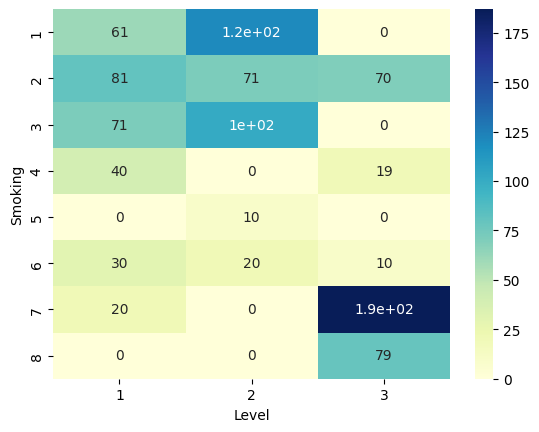

In [8]:
#perform chi-squared test for the first phase(statistical comparison)

# create a contingency table
contingency_table = pd.crosstab(cancer_df['Smoking'], cancer_df['Level'])

# perform chi-squared test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# visualize the contingency table as a heatmap
sns.heatmap(contingency_table, annot=True, cmap='YlGnBu')


# print results
print('Chi-squared test results:')
print(f'Chi-squared statistic: {chi2}')
print(f'p-value: {p_value}')


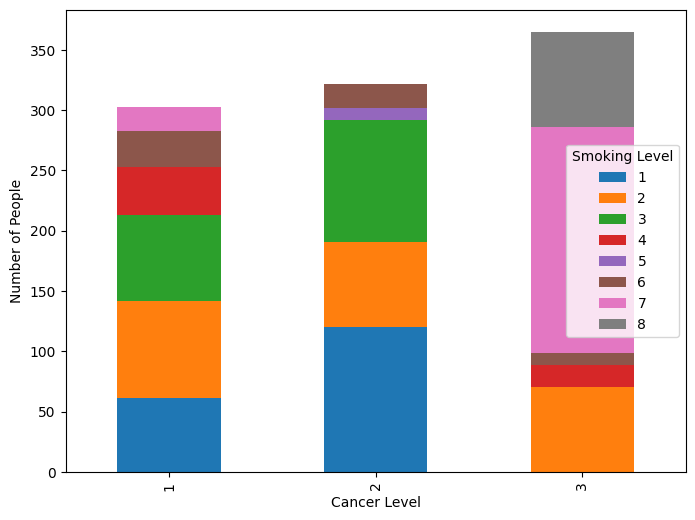

In [9]:
#another visualisation of number of people with certain smoking level in each cancer level

# Group the data by cancer level and smoking level
grouped = cancer_df.groupby(['Level', 'Smoking']).size().unstack(fill_value=0)

# Create a grouped bar chart
ax = grouped.plot(kind='bar', stacked=True, figsize=(8, 6))
ax.set_xlabel('Cancer Level')
ax.set_ylabel('Number of People')
ax.legend(title='Smoking Level')
plt.show()





In [10]:
#show mean and count and mode and medien of smoking rates in each cancer level for the first phase(statistical comparison)
# group the dataframe by cancer level and smoking rate, and calculate the count for each group
grouped_df = cancer_df.groupby(['Level', 'Smoking']).size().reset_index(name='count')
# group the dataframe by cancer level and calculate the mean, median, and mode smoking rate for each group
grouped_df_stats = cancer_df.groupby('Level')['Smoking'].agg(['mean', 'median', lambda x: x.mode().iloc[0]]).reset_index()
grouped_df_stats.columns = ['Level', 'mean', 'median', 'mode']

# merge the two dataframes
merged_df = pd.merge(grouped_df, grouped_df_stats, on='Level')

# print the mean, median, mode, and count for each smoking rate in each cancer level group
for level in merged_df['Level'].unique():
    subset_df = merged_df[merged_df['Level'] == level]
    print(f'Level {level}:')
    for index, row in subset_df.iterrows():
        smoking_rate = row['Smoking']
        mean = row['mean']
        median = row['median']
        mode = row['mode']
        count = row['count']
        print(f'  Smoking Rate {smoking_rate}: mean={mean:.2f}, median={median:.2f}, mode={mode:.2f}, count={count}')



Level 1:
  Smoking Rate 1.0: mean=3.02, median=3.00, mode=2.00, count=61.0
  Smoking Rate 2.0: mean=3.02, median=3.00, mode=2.00, count=81.0
  Smoking Rate 3.0: mean=3.02, median=3.00, mode=2.00, count=71.0
  Smoking Rate 4.0: mean=3.02, median=3.00, mode=2.00, count=40.0
  Smoking Rate 6.0: mean=3.02, median=3.00, mode=2.00, count=30.0
  Smoking Rate 7.0: mean=3.02, median=3.00, mode=2.00, count=20.0
Level 2:
  Smoking Rate 1.0: mean=2.28, median=2.00, mode=1.00, count=120.0
  Smoking Rate 2.0: mean=2.28, median=2.00, mode=1.00, count=71.0
  Smoking Rate 3.0: mean=2.28, median=2.00, mode=1.00, count=101.0
  Smoking Rate 5.0: mean=2.28, median=2.00, mode=1.00, count=10.0
  Smoking Rate 6.0: mean=2.28, median=2.00, mode=1.00, count=20.0
Level 3:
  Smoking Rate 2.0: mean=6.07, median=7.00, mode=7.00, count=70.0
  Smoking Rate 4.0: mean=6.07, median=7.00, mode=7.00, count=19.0
  Smoking Rate 6.0: mean=6.07, median=7.00, mode=7.00, count=10.0
  Smoking Rate 7.0: mean=6.07, median=7.00, mod

In [11]:
#print range of smoking for each cancer level
# Group the data by cancer level and calculate the range of smoking rate for each group
smoking_range_by_cancer_level = cancer_df.groupby('Level')['Smoking'].agg(['min', 'max'])



# Group the data by cancer level and calculate the IQR of smoking for each group
Q3=cancer_df.groupby('Level')['Smoking'].quantile(q=0.75)
Q3 = Q3.to_frame(name='Q3').reset_index()
Q1=cancer_df.groupby('Level')['Smoking'].quantile(q=0.25)
Q1 = Q1.to_frame(name='Q1').reset_index()
Q2=cancer_df.groupby('Level')['Smoking'].quantile(q=0.5)
Q2 = Q2.to_frame(name='Q2').reset_index()

iqr = cancer_df.groupby('Level')['Smoking'].quantile(q=0.75) - cancer_df.groupby('Level')['Smoking'].quantile(q=0.25)
iqr = iqr.to_frame(name='IQR').reset_index()
# Print the results
print("\nrange of smoking i each level:")
print(smoking_range_by_cancer_level)

print("\nQ1 of each level for smoking rate:")
print(Q1)
print("\nQ2 of each level for smoking rate:")
print(Q2)
print("\nQ3 of each level for smoking rate:")
print(Q3)
print("\nIQR of each level for smoking rate:")
print(iqr)





range of smoking i each level:
       min  max
Level          
1        1    7
2        1    6
3        2    8

Q1 of each level for smoking rate:
   Level   Q1
0      1  2.0
1      2  1.0
2      3  6.0

Q2 of each level for smoking rate:
   Level   Q2
0      1  3.0
1      2  2.0
2      3  7.0

Q3 of each level for smoking rate:
   Level   Q3
0      1  4.0
1      2  3.0
2      3  7.0

IQR of each level for smoking rate:
   Level  IQR
0      1  2.0
1      2  2.0
2      3  1.0


In [12]:
#calculating variance between groups for the first phase(statistical comparison)
variance_is_large=False
# calculate overall mean smoking rate
Xoverall = cancer_df['Smoking'].mean()

# group the dataframe by cancer level and calculate the mean smoking rate for each group
grouped_df = cancer_df.groupby('Level')['Smoking'].agg(['mean', 'count'])

# calculate the variance between groups
SSB = grouped_df['count'].sum() * np.sum((grouped_df['mean'] - Xoverall)**2)
sqrt=math.sqrt(SSB)
print(f'Variance between groups: {SSB}')
print(f'Standard deviation between groups: {sqrt}')

if SSB>100:
    variance_is_large=True

Variance between groups: 8034.583370821183
Standard deviation between groups: 89.63583753622868


In [13]:
#show skewness of smoking for each cancer level

# Group the data by cancer level and calculate the skewness of smoking for each group
skewness_by_cancer_level = cancer_df.groupby('Level')['Smoking'].apply(lambda x: stats.skew(x))
skewness_by_cancer_level = skewness_by_cancer_level.to_frame(name='skewness').reset_index()
# Print the results
print(skewness_by_cancer_level)

   Level  skewness
0      1  0.881892
1      2  1.217732
2      3 -1.145012


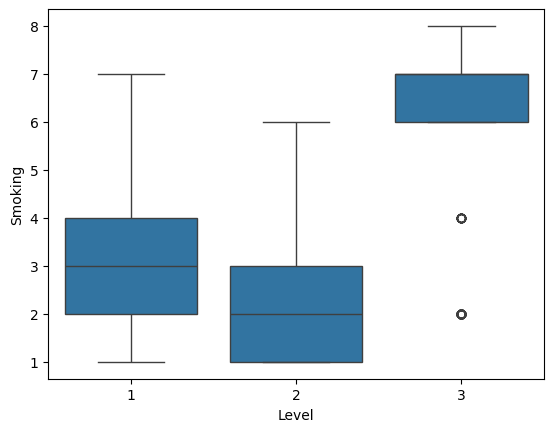

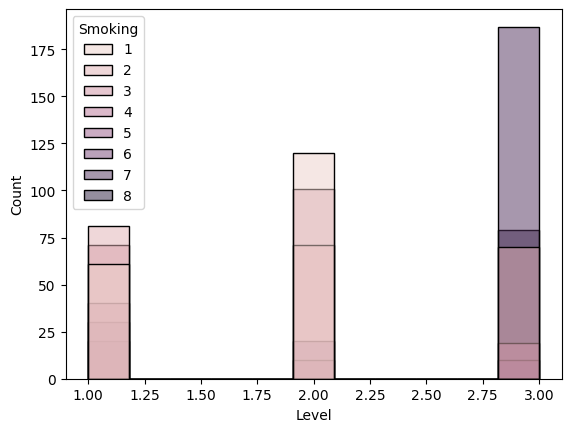

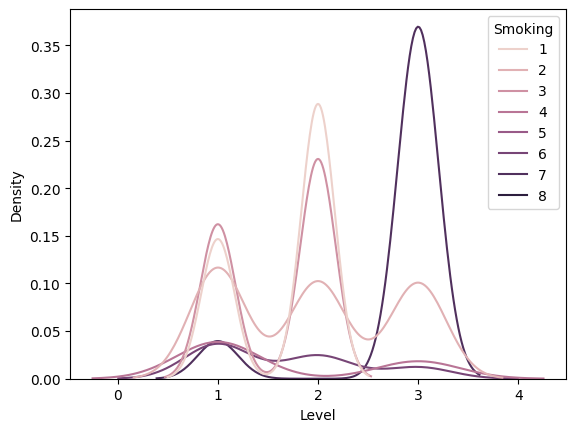

In [14]:
#show plots of level and smoking
# Create a box plot for each cancer level group
sns.boxplot(x='Level', y='Smoking', data=cancer_df)
plt.show()

# Create a histogram of smoking level for each cancer level group
sns.histplot(x='Level', hue='Smoking', data=cancer_df, kde=False)
plt.show()

# Create a density plot of smoking level for each cancer level group
sns.kdeplot(x='Level', hue='Smoking', data=cancer_df, warn_singular=False)
plt.show()



In [15]:
#check if data is normally distributed so as to see if we can use ANOVA test to see if there is statistically significant in smoke rate between the groups

# check for normality using Shapiro-Wilk test

for level in sorted(cancer_df['Level'].unique()):
    print(f'Cancer Level {level}')
    smoking_rates = cancer_df.loc[cancer_df['Level'] == level, 'Smoking']
    stat, p = shapiro(smoking_rates)
    print(f'statistic={stat:.4f}, p-value={p:.4f}')




Cancer Level 1
statistic=0.8633, p-value=0.0000
Cancer Level 2
statistic=0.7942, p-value=0.0000
Cancer Level 3
statistic=0.6948, p-value=0.0000


In [16]:
#distributions were not normal so we use Kruskal-wallies instead

# perform Kruskal-Wallis test
statistic, p_value = kruskal(cancer_df[cancer_df['Level'] == 1]['Smoking'], 
                             cancer_df[cancer_df['Level'] == 2]['Smoking'], 
                             cancer_df[cancer_df['Level'] == 3]['Smoking'])
# print results
print(f'Kruskal-Wallis statistic: {statistic:.4f}')
print(f'p-value: {p_value:.4f}')
if p_value<0.05 and variance_is_large:
    print("there are significant diferences in smoking rates between cancer groups")

Kruskal-Wallis statistic: 406.7275
p-value: 0.0000
there are significant diferences in smoking rates between cancer groups


In [17]:
#extract frequet patterns without level
new_cancer_df= cancer_df.drop('Patient Id', axis=1)
new_column_headers = list(new_cancer_df.columns.values)
for column_header in new_column_headers:
    dummies = pd.get_dummies(new_cancer_df[column_header])
    dummies_headers = list(dummies.columns.values)
    for dummies_header in dummies_headers:
        dummies.rename(columns = {dummies_header:str(column_header)+str(dummies_header)}, inplace = True)        
    new_cancer_df = pd.concat([new_cancer_df, dummies], axis=1)
    del new_cancer_df[column_header]

#extract frequent patterns:
max_frequent_items=1000
min_support = 0.1

# set display options to show all columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

#if all frequent_itemsets are desired, uncomment the next line and comment while
#frequent_itemsets=apriori(new_cancer_df,min_support=0.1,use_colnames=True)


while min_support < 1:
    frequent_itemsets=apriori(new_cancer_df,min_support=min_support,use_colnames=True)
    if frequent_itemsets.shape[0]<=max_frequent_items:
        break
    min_support=min_support+0.1

#if you want to use a min support comment while and the line above it in the code above and use the line below
#frequent_itemsets=apriori(new_cancer_df,min_support=0.5,use_colnames=True)
print("number of itemsets:", len(frequent_itemsets))
print(frequent_itemsets)
    

number of itemsets: 223
      support                                           itemsets
0    0.593939                                          (Gender1)
1    0.406061                                          (Gender2)
2    0.203030                                   (Air Pollution2)
3    0.329293                                   (Air Pollution6)
4    0.204040                                     (Alcohol use2)
5    0.409091                                    (Dust Allergy7)
6    0.368687                            (OccuPational Hazards7)
7    0.214141                                    (Genetic Risk2)
8    0.330303                                    (Genetic Risk7)
9    0.311111                            (chronic Lung Disease6)
10   0.233333                                   (Balanced Diet2)
11   0.298990                                   (Balanced Diet7)
12   0.359596                                         (Obesity7)
13   0.224242                                         (Smoking2)
1

In [18]:
#calculate all association rules
#calculate all association rules(this cell calculates rules that contain Level3 in consequents...if consequents must only have Level3 ignore this cell and run the other cell)

max_rules=1000
min_threshold = 0.1

#if all rules are desired, uncomment the next line and comment while
#rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.1)

while min_threshold < 1:
    #print(min_threshold)
    rules=association_rules(frequent_itemsets, metric='confidence', min_threshold=min_threshold)
    #print(rules.shape[0])
    if rules.shape[0]<=max_rules:
        #print(min_threshold)
        break
    min_threshold=min_threshold+0.1

#if you want to use a min threshold comment while and the line above it in the code above and use the line below
#rules=association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)


# Filter the rules to show only those with high levels of cancer
#(the line below calculates rules that contain Level3 in consequents...if consequents must only have Level3 comment the line below and uncomment the line below it
#high_cancer_rules = rules[rules['consequents'].apply(lambda x: 'Level3' in str(x))]
high_cancer_rules = rules[rules['consequents'].apply(lambda x: "frozenset({'Level3'})" == str(x))]
high_cancer_rules=high_cancer_rules[high_cancer_rules['lift']>1]


# print the rules and their size
print(high_cancer_rules)


#add rules to a csv file cause they can get so large and the file will crash
high_cancer_rules.to_csv(r'./high cancer rules.csv',encoding='utf-8', header='true', index=False)

                                           antecedents consequents  \
9                                           (Obesity7)    (Level3)   
17                                 (Gender1, Obesity7)    (Level3)   
36                          (Obesity7, Air Pollution6)    (Level3)   
37                       (Chest Pain7, Air Pollution6)    (Level3)   
64                        (Dust Allergy7, Chest Pain7)    (Level3)   
73             (Balanced Diet7, OccuPational Hazards7)    (Level3)   
78                   (Obesity7, OccuPational Hazards7)    (Level3)   
81                (Chest Pain7, OccuPational Hazards7)    (Level3)   
88                        (Genetic Risk7, Chest Pain7)    (Level3)   
92                (chronic Lung Disease6, Chest Pain7)    (Level3)   
96                       (Balanced Diet7, Chest Pain7)    (Level3)   
98                             (Obesity7, Chest Pain7)    (Level3)   
135          (Dust Allergy7, Obesity7, Air Pollution6)    (Level3)   
140       (Dust Alle

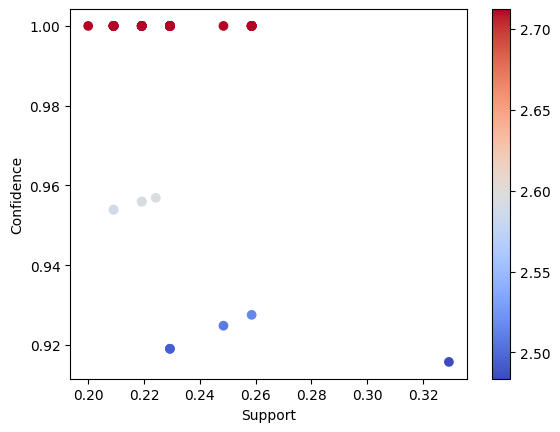

In [19]:
#apriori visualization
# Create a scatter plot of support vs. confidence
plt.scatter(high_cancer_rules['support'], high_cancer_rules['confidence'], c=high_cancer_rules['lift'], cmap='coolwarm')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.colorbar()
plt.show()